In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/Stock Price.csv")
df.head()

,mic,symbol,isin,date,open_value,high_value,low_value,last_value,change_prev_close_percentage,turnover
0,XZAG,CBX,HRZB00ICBEX6,2015-12-30,1689.22,1689.71,1673.62,1689.63,-0.02,2017520.82
1,XZAG,CBX,HRZB00ICBEX6,2015-12-29,1675.79,1691.02,1673.37,1689.94,0.84,1094356.06
2,XZAG,CBX,HRZB00ICBEX6,2015-12-28,1655.92,1677.17,1652.76,1675.88,1.21,1125687.29
3,XZAG,CBX,HRZB00ICBEX6,2015-12-23,1647.66,1655.77,1641.41,1655.77,0.49,592284.75
4,XZAG,CBX,HRZB00ICBEX6,2015-12-22,1655.71,1655.71,1642.60,1647.67,-0.55,2714509.05


In [3]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

# Set date as index
df.set_index('date', inplace=True)

# Drop missing values
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1497 entries, 2010-01-04 to 2015-12-30
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   mic                           1497 non-null   object 
 1   symbol                        1497 non-null   object 
 2   isin                          1497 non-null   object 
 3   open_value                    1497 non-null   float64
 4   high_value                    1497 non-null   float64
 5   low_value                     1497 non-null   float64
 6   last_value                    1497 non-null   float64
 7   change_prev_close_percentage  1497 non-null   float64
 8   turnover                      1497 non-null   float64
dtypes: float64(6), object(3)
memory usage: 117.0+ KB


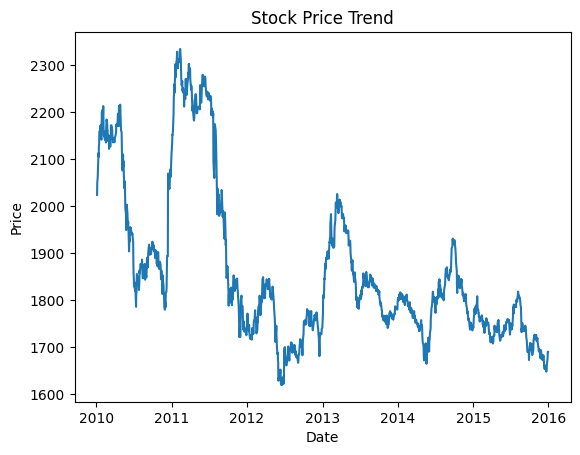

In [4]:
plt.figure()
plt.plot(df['last_value'])
plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

/tmp/ipykernel_1302/1039297949.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['last_value'].resample('M').mean()


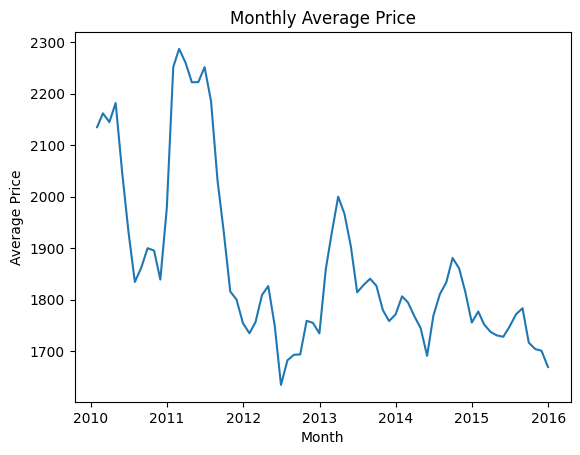

In [5]:
monthly_avg = df['last_value'].resample('M').mean()

plt.figure()
plt.plot(monthly_avg)
plt.title("Monthly Average Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()

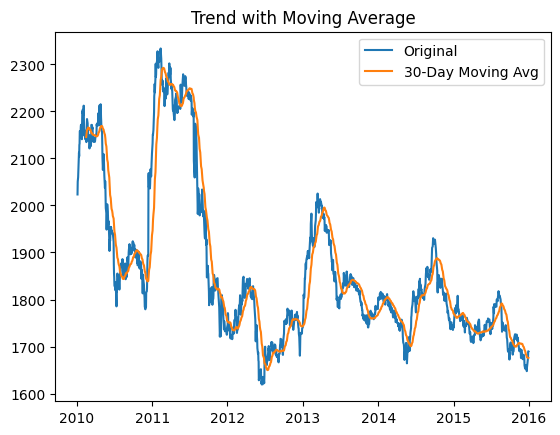

In [6]:
df['Moving_Avg'] = df['last_value'].rolling(window=30).mean()

plt.figure()
plt.plot(df['last_value'], label='Original')
plt.plot(df['Moving_Avg'], label='30-Day Moving Avg')
plt.title("Trend with Moving Average")
plt.legend()
plt.show()

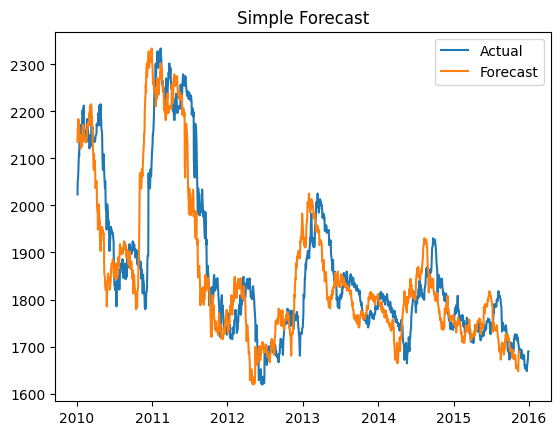

In [7]:
df['Forecast'] = df['last_value'].shift(-30)

plt.figure()
plt.plot(df['last_value'], label='Actual')
plt.plot(df['Forecast'], label='Forecast')
plt.title("Simple Forecast")
plt.legend()
plt.show()

In [8]:
print("\n--- TIME SERIES INSIGHTS ---")
print("✔ Stock shows trend over time")
print("✔ Monthly aggregation shows patterns")
print("✔ Moving average smooths noise")
print("✔ Forecast gives future estimate")


--- TIME SERIES INSIGHTS ---
✔ Stock shows trend over time
✔ Monthly aggregation shows patterns
✔ Moving average smooths noise
✔ Forecast gives future estimate
